# Spectrum of white lamps and diodes measured by spectrograph

Evgeny Kolonsky, Yulia Preesant 2026

v.0.1.8

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.interpolate import PchipInterpolator
import pandas as pd


Auxillary functions

##  Spectral sensitivity

The AvaSpec-2048L uses a Sony ILX511 CCD (front-illuminated Si CCD, 2048 pixels, 14×200 µm). The "Spectral Sensitivity Characteristics (Typ.)" curve is taken from the Sony ILX511B datasheet (p. 12). The points were manually digitized from the graph and interpolated using the PCHIP monotonic spline scheme (without oscillations).

Source: <https://spectrecology.com/wp-content/uploads/2021/03/SONY-ILX511B.pdf>

## Sensitivity Correction

We divide the measured intensity by $R(\lambda$) . At the edges, where $R$ is close to 0, this division greatly increases noise. Therefore, we set a threshold of $R$ > 0.05 and consider the data unreliable beyond this threshold.

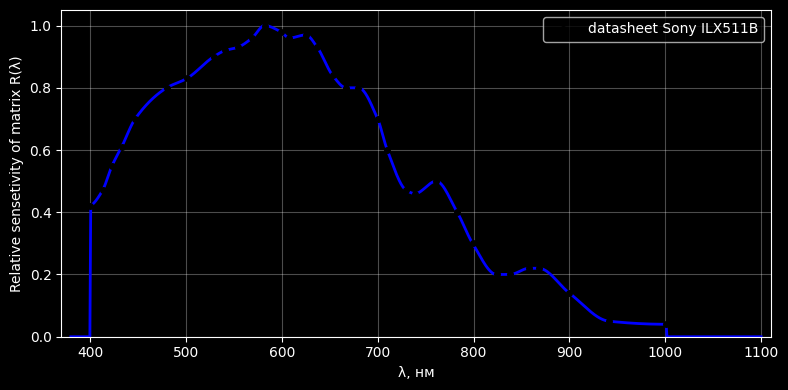

In [38]:
# Точки оцифрованы из графика Sony ILX511B
data = '''
# x	 y
400	0.42
413	0.47
423	0.55
433	0.61
447	0.70
480	0.80
501	0.83
529	0.90
541	0.92
554	0.93
569	0.96
582	1.00
599	0.98
608	0.96
625	0.97
637	0.93
653	0.84
667	0.80
680	0.80
700	0.70
710	0.60
730	0.47
739	0.46
761	0.50
783	0.40
799	0.30
824	0.20
838	0.20
858	0.22
868	0.22
900	0.14
941	0.05
1001	0.04
'''
ilx511_lam_nm,  ilx511_resp = np.genfromtxt(data.splitlines(),  unpack=True)
R_interp = PchipInterpolator(ilx511_lam_nm, ilx511_resp, extrapolate=False)

def R_lambda(lam_nm):
    # Относительная чувствительность спектрометра по λ (нм).
    r = R_interp(lam_nm)
    return np.where(np.isnan(r), 0.0, r)

# Покажем кривую
plt.figure(figsize=(8, 4))
lam_dense = np.linspace(380, 1100, 800)
plt.plot(lam_dense, R_lambda(lam_dense), 'b-', lw=2)
plt.plot(ilx511_lam_nm, ilx511_resp, 'ko', ms=4, label='datasheet Sony ILX511B')
plt.xlabel('λ, нм'); plt.ylabel('Relative sensetivity of matrix R(λ)')
#plt.title('Спектральная чувствительность Sony ILX511')
plt.grid(alpha=0.3); plt.legend()
plt.xlim(370, 1110); plt.ylim(0, 1.05)
plt.tight_layout(); plt.show()



In [46]:
def wavelength_to_rgb(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    Additionally alpha value set to 0.5 outside range
    '''
    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 750:
        A = 1.
    else:
        A = 0.5
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    return (R, G, B, A)


def get_data(name):
  url = URL.format(**locals())
  delimiters_to_try = [None, '\t', ',', ';', ' ']
  df = None

  for delimiter in delimiters_to_try:
    try:
      # `header=None` assumes no header row after skipping `skiprows`
      # `usecols=[0,4]` selects the 0th and 4th columns (0-indexed)
      # `sep=None` allows pandas to infer the separator, `engine='python'` for robust inference.
      df = pd.read_csv(url, skiprows=8, header=None, usecols=[0, 4], sep=delimiter, engine='python')
      if df is not None:
        break
    except (pd.errors.ParserError, ValueError) as e:
      print(f"Attempt with delimiter '{delimiter}' failed for {name}: {e}")
      continue

  if df is None:
    raise ValueError(f"Could not parse data from {name} with any tested delimiter.")

  # Extract waves and counts from the DataFrame. Columns will be named 0 and 4 as per usecols.
  waves = df[0].values
  counts = df[4].values
  peaks, _ = find_peaks(counts, height=200, prominence=1000)
  return waves, counts, peaks



def wavelength_to_rgb(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    Additionally alpha value set to 0.5 outside range
    '''
    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 750:
        A = 1.
    else:
        A = 0.5
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    return (R, G, B, A)

def get_data(name):
  url = URL.format(**locals())
  delimiters_to_try = [None, '\t', ',', ';', ' ']
  df = None

  for delimiter in delimiters_to_try:
    try:
      # `header=None` assumes no header row after skipping `skiprows`
      # `usecols=[0,4]` selects the 0th and 4th columns (0-indexed)
      # `sep=None` allows pandas to infer the separator, `engine='python'` for robust inference.
      df = pd.read_csv(url, skiprows=8, header=None, usecols=[0, 4], sep=delimiter, engine='python')
      if df is not None:
        break
    except (pd.errors.ParserError, ValueError) as e:
      print(f"Attempt with delimiter '{delimiter}' failed for {name}: {e}")
      continue

  if df is None:
    raise ValueError(f"Could not parse data from {name} with any tested delimiter.")

  waves = df[0].values
  counts = df[4].values
  peaks, _ = find_peaks(counts, height=200, prominence=1000)
  return waves, counts, peaks


/tmp/ipykernel_2720/1557425850.py:11: RuntimeWarning: divide by zero encountered in divide
  intensity = counts / R_lambda(waves)
/tmp/ipykernel_2720/1557425850.py:11: RuntimeWarning: divide by zero encountered in divide
  intensity = counts / R_lambda(waves)
/tmp/ipykernel_2720/1557425850.py:11: RuntimeWarning: divide by zero encountered in divide
  intensity = counts / R_lambda(waves)
/tmp/ipykernel_2720/1557425850.py:11: RuntimeWarning: divide by zero encountered in divide
  intensity = counts / R_lambda(waves)


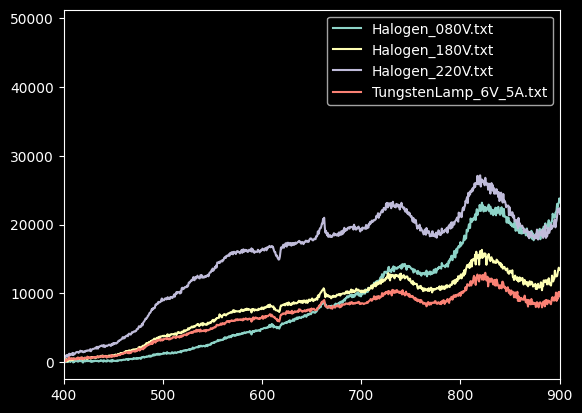

In [54]:
URL =  'https://raw.githubusercontent.com/tphlabs/data/refs/heads/main/Lab4_SP/2026.04/{name}'

names = '''Halogen_080V.txt
Halogen_180V.txt
Halogen_220V.txt
TungstenLamp_6V_5A.txt
'''.splitlines()

for name in names:
    waves, counts, peaks = get_data(name)
    intensity = counts / R_lambda(waves)
    plt.plot(waves, intensity, label=name)
    plt.legend()
    plt.xlim(400, 900)


/tmp/ipykernel_2720/4037950374.py:11: RuntimeWarning: divide by zero encountered in divide
  intensity = counts / R_lambda(waves)
/tmp/ipykernel_2720/4037950374.py:11: RuntimeWarning: invalid value encountered in divide
  intensity = counts / R_lambda(waves)
/tmp/ipykernel_2720/4037950374.py:11: RuntimeWarning: divide by zero encountered in divide
  intensity = counts / R_lambda(waves)
/tmp/ipykernel_2720/4037950374.py:11: RuntimeWarning: divide by zero encountered in divide
  intensity = counts / R_lambda(waves)
/tmp/ipykernel_2720/4037950374.py:11: RuntimeWarning: invalid value encountered in divide
  intensity = counts / R_lambda(waves)
/tmp/ipykernel_2720/4037950374.py:11: RuntimeWarning: divide by zero encountered in divide
  intensity = counts / R_lambda(waves)


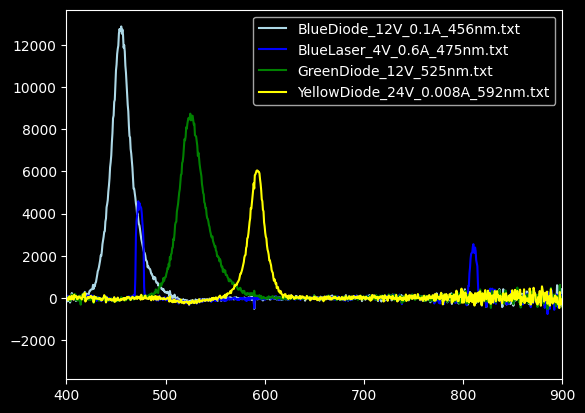

In [55]:
names = '''BlueDiode_12V_0.1A_456nm.txt
BlueLaser_4V_0.6A_475nm.txt
GreenDiode_12V_525nm.txt
YellowDiode_24V_0.008A_592nm.txt
'''.splitlines()

colors = ['lightblue', 'blue', 'green', 'yellow']

for i, name in enumerate(names):
    waves, counts, peaks = get_data(name)
    intensity = counts / R_lambda(waves)
    plt.plot(waves, intensity, label=name, color=colors[i])
    plt.legend()
    plt.xlim(400, 900)